           Country Name          2022
109               India  1.417173e+09
40                China  1.412175e+09
251       United States  3.332876e+08
106           Indonesia  2.755013e+08
184            Pakistan  2.358249e+08
174             Nigeria  2.185412e+08
29               Brazil  2.153135e+08
20           Bangladesh  1.711864e+08
202  Russian Federation  1.442369e+08
154              Mexico  1.275041e+08
119               Japan  1.251250e+08
72             Ethiopia  1.233799e+08
187         Philippines  1.155590e+08
67     Egypt, Arab Rep.  1.109901e+08
43     Congo, Dem. Rep.  9.901021e+07


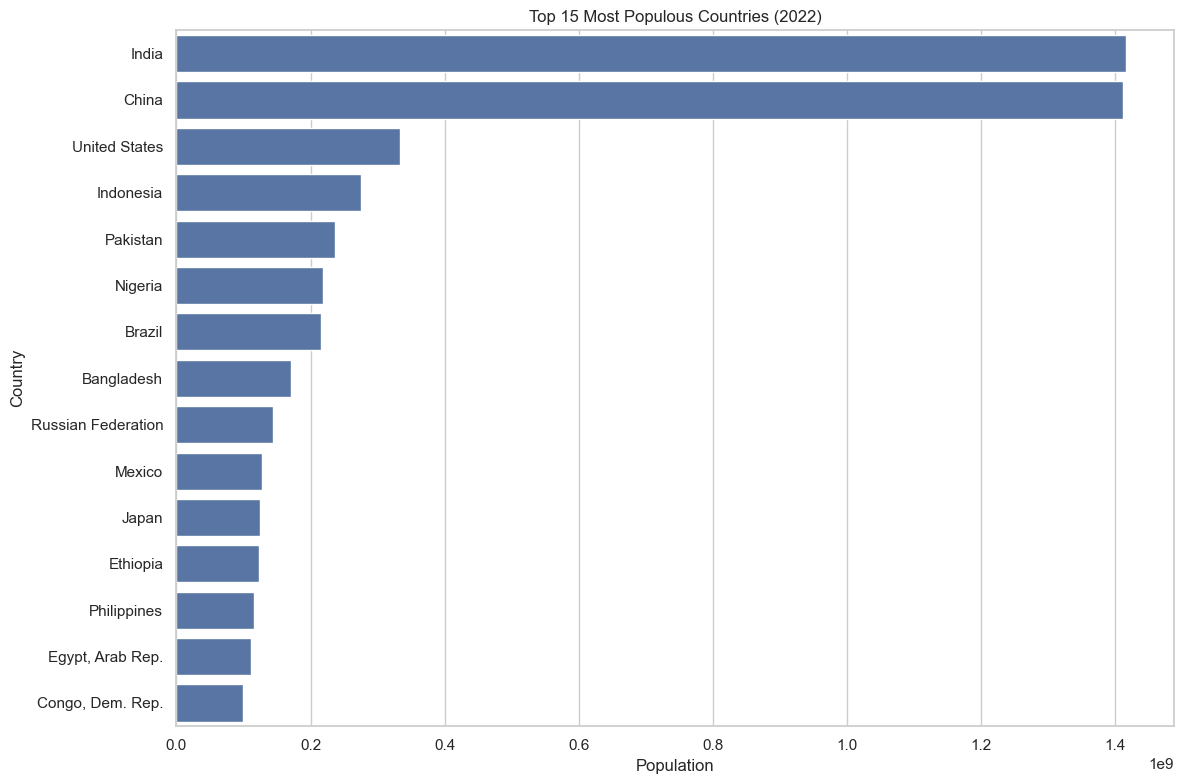

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("population.csv")


df.columns = df.columns.str.strip()


df['2022'] = pd.to_numeric(df['2022'], errors='coerce')

  
df = df.dropna()

df = df[df['Country Code'].str.fullmatch(r'[A-Z]{3}')]


df = df[~df['Country Name'].str.contains(
    "income|IDA|IBRD|demographic|Fragile|HIPC|OECD|World|Euro|Asia|Africa|Europe|America|Least developed",
    case=False, na=False
)]

# Sort properly
df = df.sort_values(by='2022', ascending=False)

# Get top 15
top15 = df[['Country Name', '2022']].head(15)


print(top15)

# Plot
plt.figure(figsize=(12,8))
sns.barplot(x='2022', y='Country Name', data=top15)

plt.title("Top 15 Most Populous Countries (2022)")
plt.xlabel("Population")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

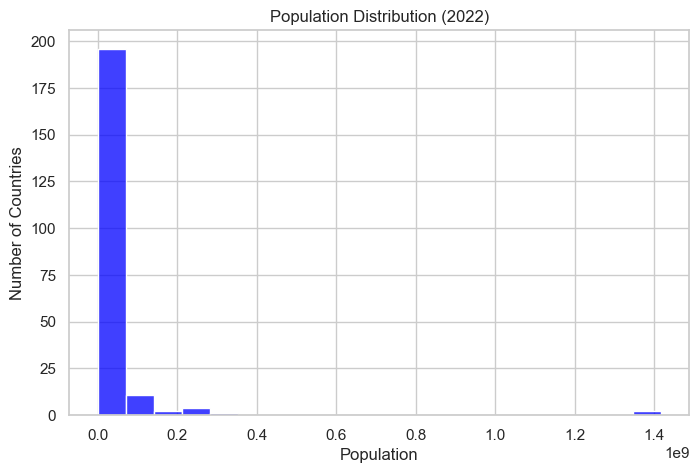

In [24]:

df = df[df['Country Code'].str.len() == 3]
df['2022'] = pd.to_numeric(df['2022'], errors='coerce')
df = df.dropna()
plt.figure(figsize=(8,5))
sns.histplot(df['2022'], bins=20, color='blue')

plt.title("Population Distribution (2022)")
plt.xlabel("Population")
plt.ylabel("Number of Countries")

plt.grid(True)
plt.show()